# Machine Learning Training Section

Support Vector Machine, Gradient Boosted Trees, and Random Forest

 1. **Split** the dataset for testing and validation into folds.
 1. **Select** a machine learning algorithm to be tested with the dataset by importing a specific machine learning algorithm in scikit-learn library.
 1. **Train** using the training folds and will be tested and evaluated using the validation folds wherein the researchers will also observe its accuracy, detection rate, recall, precision, false positive rate and take the average of it.
 1. **Evaluate** the combinations of the hyperparameters to maximize the performance of the model.          
 *If the best combination is found, then it will proceed to the next step. If not, then it will undergo hyperparameter tuning to find the best combination of the hyperparameters and will undergo training with the tuned hyperparameters.*
 1. The model will then be compared with the performance of other models to determine the best based on the given evaluation metrics.
 1. The best performing model will be then tested using the testing set that is still unseen by the model.

**Input** -===- Preprocessed Dataset

**Output** -==- Model & Scaler Output

In [1]:
%pip install pandas numpy matplotlib scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.colors import LogNorm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, confusion_matrix

from sklearn.preprocessing import StandardScaler



In [3]:
from sklearn.metrics import make_scorer, confusion_matrix

def multiclass_weighted_fpr(y_true, y_pred):
    """Calculates the weighted False Positive Rate for multiclass classification."""
    cm = confusion_matrix(y_true, y_pred)

    # FP: Column sum - TP (diagonal)
    fp = cm.sum(axis=0) - np.diag(cm)
    # FN: Row sum - TP (diagonal)
    fn = cm.sum(axis=1) - np.diag(cm)
    # TP: Diagonal
    tp = np.diag(cm)
    # TN: Total - (FP + FN + TP)
    tn = cm.sum() - (fp + fn + tp)

    # FPR = FP / (FP + TN)
    fpr = fp / (fp + tn)

    # Handle potential division by zero
    fpr = np.nan_to_num(fpr)

    # Return weighted average based on class support (row sums)
    weights = cm.sum(axis=1)
    return np.average(fpr, weights=weights)

# Create the scorer object
fpr_scorer = make_scorer(multiclass_weighted_fpr)

In [4]:
train = "../datasets/final_train.csv"
test = "../datasets/test.csv"

df = pd.read_csv(train)
test_df = pd.read_csv(test)

df.head()



,local_resp,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,service_dce_rpc,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssl,service_unknown,label_tactic
0,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,Credential Access
1,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access
2,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,Credential Access
3,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,Credential Access
4,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,Credential Access


In [5]:
'''
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

if has_smote:
    sm = SMOTE(random_state=42)
    X_train_scaled, y_train = sm.fit_resample(X_train_scaled, y_train)
    print('Applied SMOTE.')
    '''

"\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.2, random_state=42, stratify=y\n)\n\nscaler = StandardScaler()\nX_train_scaled = scaler.fit_transform(X_train)\nX_test_scaled = scaler.transform(X_test)\n\nif has_smote:\n    sm = SMOTE(random_state=42)\n    X_train_scaled, y_train = sm.fit_resample(X_train_scaled, y_train)\n    print('Applied SMOTE.')\n    "

In [6]:

X_train = df.drop(columns=["label_tactic"])
y_train = df["label_tactic"]

X_test = test_df.drop(columns=["label_tactic"])
y_test = test_df["label_tactic"]


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

If output is unsatisfactory, try benign malicious.

Try Tenfold cross validation

Or stratified kfold

Priviledge Escalation > Privilege Escalation

Gridsearch for hyperparameter tuning

# Random Forest Section
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [8]:
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV

gbt = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbt.fit(X_train_scaled, y_train)

# Perform 10-fold cross-validation with multiple metrics
scoring = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted',
    'fpr_weighted': fpr_scorer  # Add our custom scorer here
}

skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(
    gbt,
    X_train_scaled,
    y_train,
    cv=skf_10,
    scoring=scoring,
    return_train_score=True,
    n_jobs=2  # Reduced from -1 to limit memory usage
)

# Build fold-by-fold report
cv_df = pd.DataFrame({
    "fold": np.arange(1, 11),
    "train_accuracy": cv_results["train_accuracy"],
    "test_accuracy": cv_results["test_accuracy"],
    "train_precision_weighted": cv_results["train_precision_weighted"],
    "test_precision_weighted": cv_results["test_precision_weighted"],
    "train_recall_weighted": cv_results["train_recall_weighted"],
    "test_recall_weighted": cv_results["test_recall_weighted"],
    "train_f1_weighted": cv_results["train_f1_weighted"],
    "test_f1_weighted": cv_results["test_f1_weighted"],
    "fit_time_sec": cv_results["fit_time"],
    "score_time_sec": cv_results["score_time"],
    "train_fpr": cv_results["train_fpr_weighted"],  # Training FPR
    "test_fpr": cv_results["test_fpr_weighted"],    # Validation FPR
})

print("10-Fold Cross-Validation (Fold-by-Fold):")
print(cv_df.round(4).to_string(index=False))

print("\nSummary (test metrics):")
for metric in ["test_accuracy", "test_precision_weighted", "test_recall_weighted", "test_f1_weighted"]:
    vals = cv_results[metric]
    print(
        f"{metric}: mean={vals.mean():.4f}, std={vals.std():.4f}, "
        f"min={vals.min():.4f}, max={vals.max():.4f}"
    )

print("\nGeneralization gap (train - test, mean):")
for metric in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]:
    gap = cv_results[f"train_{metric}"].mean() - cv_results[f"test_{metric}"].mean()
    print(f"{metric}: {gap:.4f}")

# Grid search with reduced parameter space and limited parallelization
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2] 
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=2,  # Reduced from -1 to limit memory usage
    verbose=1  # Added to monitor progress
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

10-Fold Cross-Validation (Fold-by-Fold):
 fold  train_accuracy  test_accuracy  train_precision_weighted  test_precision_weighted  train_recall_weighted  test_recall_weighted  train_f1_weighted  test_f1_weighted  fit_time_sec  score_time_sec  train_fpr  test_fpr
    1          0.9137         0.9128                    0.9306                   0.8592                 0.9137                0.9128             0.8830            0.8821      358.7244          0.5782     0.0461    0.0466
    2          0.9134         0.9153                    0.9304                   0.8610                 0.9134                0.9153             0.8827            0.8844      353.6648          0.7471     0.0463    0.0452
    3          0.9138         0.9129                    0.9003                   0.8596                 0.9138                0.9129             0.8830            0.8823      350.4183          0.6088     0.0461    0.0465
    4          0.9136         0.9136                    0.9305             

In [9]:

y_pred = gbt.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

c:\Users\Aaron\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Aaron\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                      precision    recall  f1-score   support

   Credential Access       1.00      1.00      1.00      8699
           Discovery       0.77      1.00      0.87     13431
Resource Development       0.00      0.00      0.00      2723
                none       1.00      0.96      0.98     27403

            accuracy                           0.92     52256
           macro avg       0.69      0.74      0.71     52256
        weighted avg       0.89      0.92      0.90     52256



c:\Users\Aaron\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


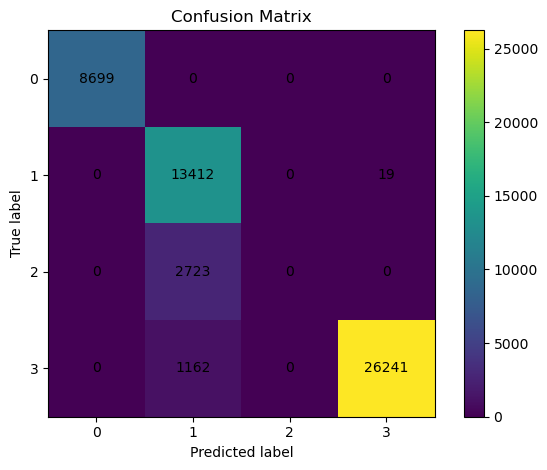

In [10]:



# Generate predictions first (use tuned model if available)
y_pred = grid_search.best_estimator_.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

# Annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


In [11]:
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train)

# Perform 10-fold cross-validation with multiple metrics (verbose output)
scoring = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted',
    'fpr_weighted': fpr_scorer  # Add our custom scorer here
}

skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(
    rf,
    X_train_scaled,
    y_train,
    cv=skf_10,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# Build fold-by-fold report
cv_df = pd.DataFrame({
    "fold": np.arange(1, 11),
    "train_accuracy": cv_results["train_accuracy"],
    "test_accuracy": cv_results["test_accuracy"],
    "train_precision_weighted": cv_results["train_precision_weighted"],
    "test_precision_weighted": cv_results["test_precision_weighted"],
    "train_recall_weighted": cv_results["train_recall_weighted"],
    "test_recall_weighted": cv_results["test_recall_weighted"],
    "train_f1_weighted": cv_results["train_f1_weighted"],
    "test_f1_weighted": cv_results["test_f1_weighted"],
    "fit_time_sec": cv_results["fit_time"],
    "score_time_sec": cv_results["score_time"],
    "train_fpr": cv_results["train_fpr_weighted"],  # Training FPR
    "test_fpr": cv_results["test_fpr_weighted"],    # Validation FPR
})

print("10-Fold Cross-Validation (Fold-by-Fold):")
print(cv_df.round(4).to_string(index=False))

print("\nSummary (test metrics):")
for metric in ["test_accuracy", "test_precision_weighted", "test_recall_weighted", "test_f1_weighted"]:
    vals = cv_results[metric]
    print(
        f"{metric}: mean={vals.mean():.4f}, std={vals.std():.4f}, "
        f"min={vals.min():.4f}, max={vals.max():.4f}"
    )

print("\nGeneralization gap (train - test, mean):")
for metric in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]:
    gap = cv_results[f"train_{metric}"].mean() - cv_results[f"test_{metric}"].mean()
    print(f"{metric}: {gap:.4f}")

# Grid search with reduced parameter space and limited parallelization
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=2,  # Reduced from -1 to limit memory usage
    verbose=1  # Added to monitor progress
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


10-Fold Cross-Validation (Fold-by-Fold):
 fold  train_accuracy  test_accuracy  train_precision_weighted  test_precision_weighted  train_recall_weighted  test_recall_weighted  train_f1_weighted  test_f1_weighted  fit_time_sec  score_time_sec  train_fpr  test_fpr
    1          0.8651         0.8655                    0.8943                   0.8932                 0.8651                0.8655             0.8769            0.8768       54.8601          0.9581     0.0333    0.0340
    2          0.8650         0.8663                    0.8939                   0.8964                 0.8650                0.8663             0.8767            0.8783       54.2049          1.3270     0.0335    0.0321
    3          0.8649         0.8677                    0.8941                   0.8947                 0.8649                0.8677             0.8767            0.8787       54.4121          1.2281     0.0334    0.0335
    4          0.8656         0.8612                    0.8945             

In [12]:

y_pred = rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

   Credential Access       1.00      1.00      1.00      8699
           Discovery       0.80      0.76      0.78     13431
Resource Development       0.29      0.50      0.37      2723
                none       1.00      0.96      0.98     27403

            accuracy                           0.89     52256
           macro avg       0.77      0.80      0.78     52256
        weighted avg       0.91      0.89      0.90     52256



In [ ]:
from sklearn.metrics import confusion_matrix

# Generate predictions first (use tuned model if available)
y_pred = grid_search.best_estimator_.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.clim(0, cm.max())
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

# Annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


NameError: name 'grid_search' is not defined

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV

# Explicit SVM hyperparameters for 10-fold CV
svm = SVC(
    kernel='rbf',
    C=10,
    gamma=0.01,
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm.fit(X_train_scaled, y_train)

# Perform 10-fold cross-validation with multiple metrics
scoring = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted',
    'fpr_weighted': fpr_scorer
}

skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(
    svm,
    X_train_scaled,
    y_train,
    cv=skf_10,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# Build fold-by-fold report
cv_df = pd.DataFrame({
    "fold": np.arange(1, 11),
    "train_accuracy": cv_results["train_accuracy"],
    "test_accuracy": cv_results["test_accuracy"],
    "train_precision_weighted": cv_results["train_precision_weighted"],
    "test_precision_weighted": cv_results["test_precision_weighted"],
    "train_recall_weighted": cv_results["train_recall_weighted"],
    "test_recall_weighted": cv_results["test_recall_weighted"],
    "train_f1_weighted": cv_results["train_f1_weighted"],
    "test_f1_weighted": cv_results["test_f1_weighted"],
    "fit_time_sec": cv_results["fit_time"],
    "score_time_sec": cv_results["score_time"],
    "train_fpr": cv_results["train_fpr_weighted"],  # Training FPR
    "test_fpr": cv_results["test_fpr_weighted"],    # Validation FPR
})

print("10-Fold Cross-Validation (Fold-by-Fold):")
print(cv_df.round(4).to_string(index=False))

print("\nSummary (test metrics):")
for metric in ["test_accuracy", "test_precision_weighted", "test_recall_weighted", "test_f1_weighted"]:
    vals = cv_results[metric]
    print(
        f"{metric}: mean={vals.mean():.4f}, std={vals.std():.4f}, "
        f"min={vals.min():.4f}, max={vals.max():.4f}"
    )

print("\nGeneralization gap (train - test, mean):")
for metric in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]:
    gap = cv_results[f"train_{metric}"].mean() - cv_results[f"test_{metric}"].mean()
    print(f"{metric}: {gap:.4f}")


# Grid search for hyperparameter tuning
param_grid = {
    'C': [1, 10],
    'gamma': ['scale', 0.01]
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=42),
    param_grid,
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


In [ ]:

y_pred = svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9122
           1       1.00      1.00      1.00      9322

    accuracy                           1.00     18444
   macro avg       1.00      1.00      1.00     18444
weighted avg       1.00      1.00      1.00     18444



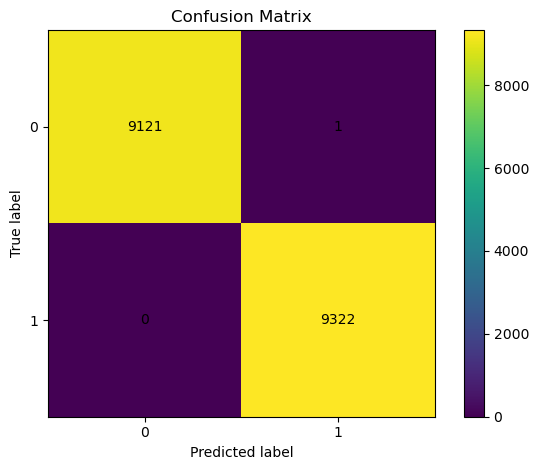

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate predictions first (use tuned model if available)
y_pred = svm.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

# Annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


# REGULAR


In [ ]:
train = 'final.csv'
test = 'test.csv'

df = pd.read_csv(train)
test_df = pd.read_csv(test)

df.head()

,Unnamed: 0,duration_bin_1.0,duration_bin_2.0,duration_bin_3.0,duration_bin_4.0,duration_bin_5.0,duration_bin_6.0,missed_bytes_bin_1.0,missed_bytes_bin_2.0,orig_bytes_bin_1.0,...,service_dce_rpc,service_ntlm,service_smb,service_gssapi,service_dns,service_http,service_ntp,service_ssl,service_unknown,label_tactic
0,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,Credential Access
1,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,Credential Access
2,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,Credential Access
3,3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,Credential Access
4,4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,Credential Access


In [ ]:
X_train = df.drop(columns=["label_tactic"])
y_train = df["label_tactic"]

X_test = test_df.drop(columns=["label_tactic"])
y_test = test_df["label_tactic"]

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV

# Explicit SVM hyperparameters for 10-fold CV
svm = SVC(
    kernel='rbf',
    C=10,
    gamma=0.01,
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm.fit(X_train_scaled, y_train)

# Perform 10-fold cross-validation with multiple metrics
scoring = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted',
    'fpr_weighted': fpr_scorer
}

skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(
    svm,
    X_train_scaled,
    y_train,
    cv=skf_10,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# Build fold-by-fold report
cv_df = pd.DataFrame({
    "fold": np.arange(1, 11),
    "train_accuracy": cv_results["train_accuracy"],
    "test_accuracy": cv_results["test_accuracy"],
    "train_precision_weighted": cv_results["train_precision_weighted"],
    "test_precision_weighted": cv_results["test_precision_weighted"],
    "train_recall_weighted": cv_results["train_recall_weighted"],
    "test_recall_weighted": cv_results["test_recall_weighted"],
    "train_f1_weighted": cv_results["train_f1_weighted"],
    "test_f1_weighted": cv_results["test_f1_weighted"],
    "fit_time_sec": cv_results["fit_time"],
    "score_time_sec": cv_results["score_time"],
    "train_fpr": cv_results["train_fpr_weighted"],  # Training FPR
    "test_fpr": cv_results["test_fpr_weighted"],    # Validation FPR
})

print("10-Fold Cross-Validation (Fold-by-Fold):")
print(cv_df.round(4).to_string(index=False))

print("\nSummary (test metrics):")
for metric in ["test_accuracy", "test_precision_weighted", "test_recall_weighted", "test_f1_weighted"]:
    vals = cv_results[metric]
    print(
        f"{metric}: mean={vals.mean():.4f}, std={vals.std():.4f}, "
        f"min={vals.min():.4f}, max={vals.max():.4f}"
    )

print("\nGeneralization gap (train - test, mean):")
for metric in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]:
    gap = cv_results[f"train_{metric}"].mean() - cv_results[f"test_{metric}"].mean()
    print(f"{metric}: {gap:.4f}")


# Grid search for hyperparameter tuning
param_grid = {
    'C': [1, 10],
    'gamma': ['scale', 0.01]
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=42),
    param_grid,
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


10-Fold Cross-Validation (Fold-by-Fold):
 fold  train_accuracy  test_accuracy  train_precision_weighted  test_precision_weighted  train_recall_weighted  test_recall_weighted  train_f1_weighted  test_f1_weighted  fit_time_sec  score_time_sec  train_fpr  test_fpr
    1             1.0            1.0                       1.0                      1.0                    1.0                   1.0                1.0               1.0       13.6004          0.1252        0.0       0.0
    2             1.0            1.0                       1.0                      1.0                    1.0                   1.0                1.0               1.0       20.5785          0.1072        0.0       0.0
    3             1.0            1.0                       1.0                      1.0                    1.0                   1.0                1.0               1.0       13.6199          0.1627        0.0       0.0
    4             1.0            1.0                       1.0             

In [ ]:

y_pred = svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9122
           1       1.00      1.00      1.00      9322

    accuracy                           1.00     18444
   macro avg       1.00      1.00      1.00     18444
weighted avg       1.00      1.00      1.00     18444



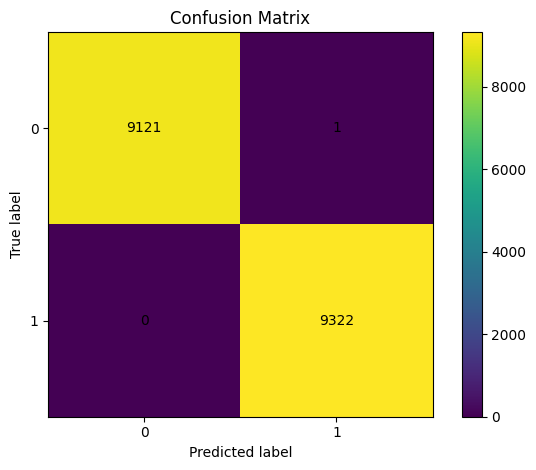

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate predictions first (use tuned model if available)
y_pred = svm.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

# Annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()
